____
__Universidad de San Andrés__<br/>
__Visión Artificial__<br/>
__Detección de autos y estimación de velocidades__<br/>
__Martín Bianchi, Agustín Amblard y Federico Gutman__
____

### Importamos las librerías necesarias

In [ ]:
from pathlib import Path
import random
import shutil
import cv2

from src.loading import load_dataset_subset
from src.visualization import preview_sequence_grid
from src.augmentation import apply_dirty_effect, apply_random_weather

### Cargamos los datos

In [26]:
TRACKING_ROOT = Path.cwd()
DETRAC_ROOT = TRACKING_ROOT / "DETRAC_Upload"
MIXED_ROOT = TRACKING_ROOT / "DETRAC_mixed_50_50"

print("TRACKING_ROOT:", TRACKING_ROOT)
print("DETRAC_ROOT existe:", DETRAC_ROOT.exists())
print("MIXED_ROOT existe:", MIXED_ROOT.exists())

TRACKING_ROOT: /Users/fedegutman/Desktop/VisionTrafficGuard/tracking
DETRAC_ROOT existe: True
MIXED_ROOT existe: False


In [27]:
subset_clean = load_dataset_subset(
    base_dir=DETRAC_ROOT,
    split="train",
    percent=5.0,    # porcentaje de los datos cargados
    shuffle=True,
)

clean_image_paths = subset_clean["image_paths"]
clean_label_paths = subset_clean["label_paths"]

len(clean_image_paths), clean_image_paths[0]

Total imágenes en train: 82085 | Usando: 4104 (5.0%)


(4104,
 PosixPath('/Users/fedegutman/Desktop/VisionTrafficGuard/tracking/DETRAC_Upload/images/train/MVI_40152_img00786.jpg'))

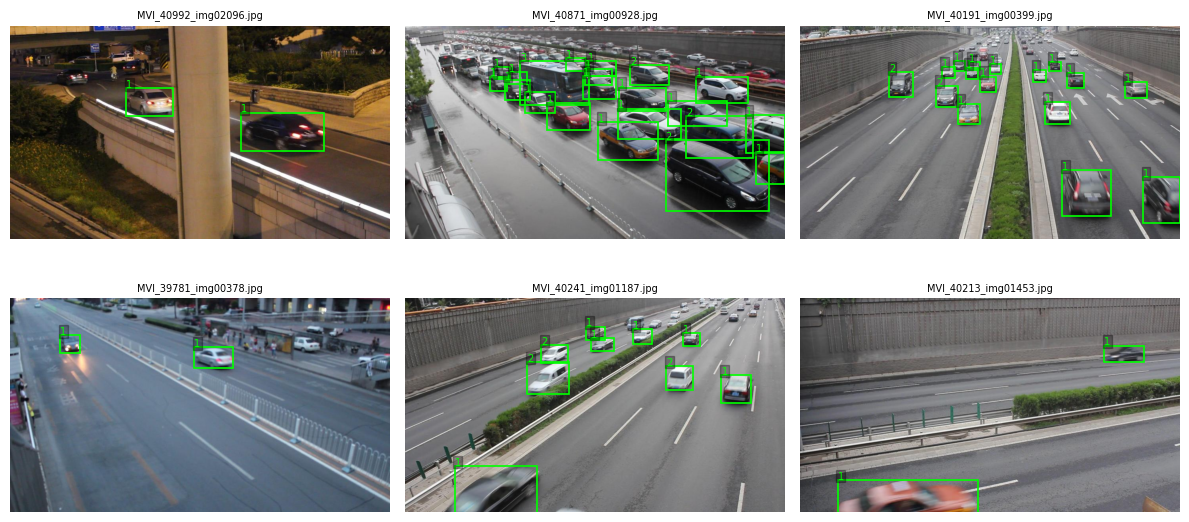

In [28]:
preview_sequence_grid(
    image_paths=clean_image_paths,
    sequence_filter=None,
    n_rows=2,
    n_cols=3,
    random_sample=True,
    show_boxes=True,
    labels_root=DETRAC_ROOT / "labels" / "train"
)

### Aplicamos condiciones climáticas adversas a las imágenes

In [29]:
WEATHER_ROOT = TRACKING_ROOT / "DETRAC_weather"
WEATHER_IMAGES_DIR = WEATHER_ROOT / "images"
WEATHER_LABELS_DIR = WEATHER_ROOT / "labels"

WEATHER_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
WEATHER_LABELS_DIR.mkdir(parents=True, exist_ok=True)

print("Weather dir:", WEATHER_ROOT)


Weather dir: /Users/fedegutman/Desktop/VisionTrafficGuard/tracking/DETRAC_weather


In [30]:
indices = list(range(len(clean_image_paths)))
random.shuffle(indices)

n_weather = len(indices) // 2
weather_idx = set(indices[:n_weather])
clean_idx_weather = set(indices[n_weather:])

print("Total:", len(indices), "| weather:", len(weather_idx), "| clean:", len(clean_idx_weather))

Total: 4104 | weather: 2052 | clean: 2052


In [ ]:
weather_image_paths = []

for i, (img_path, lbl_path) in enumerate(zip(clean_image_paths, clean_label_paths)):
    
    img = cv2.imread(str(img_path))
    if img is None:
        print("Error leyendo imagen:", img_path)
        continue

    base_name = img_path.stem # esto es tipo "IMG_00123"
    ext = img_path.suffix # y esto ".jpg"
    
    if i in weather_idx:
        # aplicar clima y obtener nombre
        img_weather, effect_name = apply_random_weather(img)

        # nuevo nombre: IMG_00123_RAIN.jpg (se le agrega el clima al final)
        out_img = WEATHER_IMAGES_DIR / f"{base_name}_{effect_name}{ext}"
        cv2.imwrite(str(out_img), img_weather)

    else:
        # dejar imagen limpia: IMG_00123_CLEAR.jpg
        out_img = WEATHER_IMAGES_DIR / f"{base_name}_CLEAR{ext}"
        shutil.copy2(img_path, out_img)

    # copiar label con mismo nombre base
    out_lbl = WEATHER_LABELS_DIR / f"{base_name}.txt"
    shutil.copy2(lbl_path, out_lbl)

    weather_image_paths.append(out_img)

len(weather_image_paths)

4104

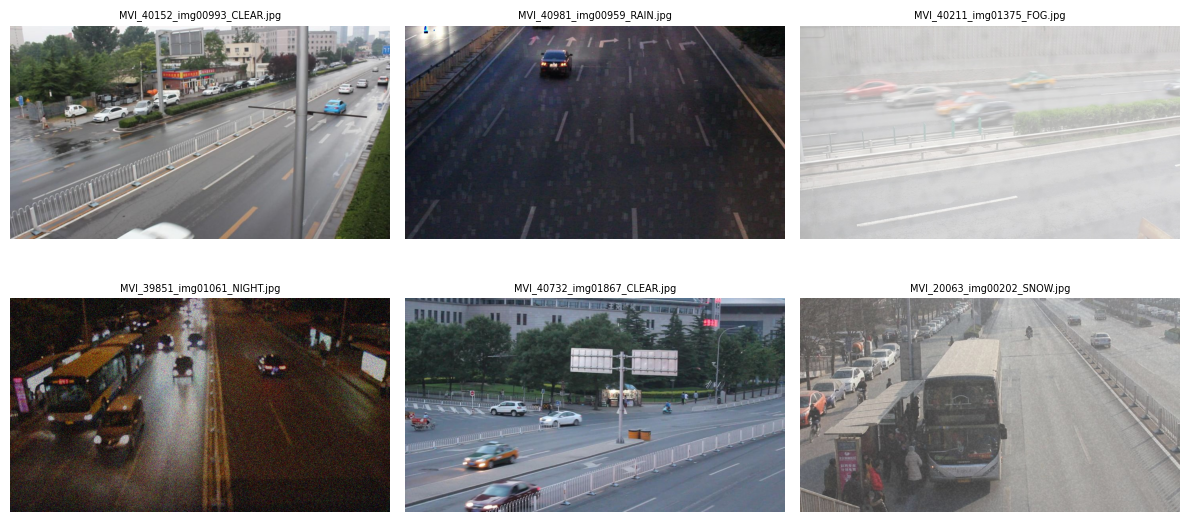

In [37]:
preview_sequence_grid(
    image_paths=weather_image_paths,
    n_rows=2,
    n_cols=3,
    random_sample=True,
    show_boxes=True,
    labels_root=DETRAC_ROOT / "labels" / "train"
)